In [8]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

In [ ]:
X, Y = 50, 50
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)

T_list = np.concatenate([
    [0.001],
    np.arange(0.01, 0.25 + 1e-12, 0.01),
    np.arange(0.26, 0.37 + 1e-12, 0.005),
    np.arange(0.38, 0.45 + 1e-12, 0.01)
])

U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [ ]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import copy

In [10]:
def run_T(T):
    H_local = copy.deepcopy(H)
    F_swave, F_dwave, F_px, F_py = bdg_sc(
        H_local, rtol=0.1, maxiter=10000, verbose=False, temperature=T
    )
    return (
        np.mean(F_px),
        np.mean(F_py),
        np.mean(F_swave),
        np.mean(F_dwave),
    )

results = Parallel(n_jobs=-1)(
    delayed(run_T)(T) for T in tqdm(T_list)
)

F_px_arr, F_py_arr, F_swave_arr, F_dwave_arr = map(np.array, zip(*results))

  0%|          | 0/72 [00:00<?, ?it/s]

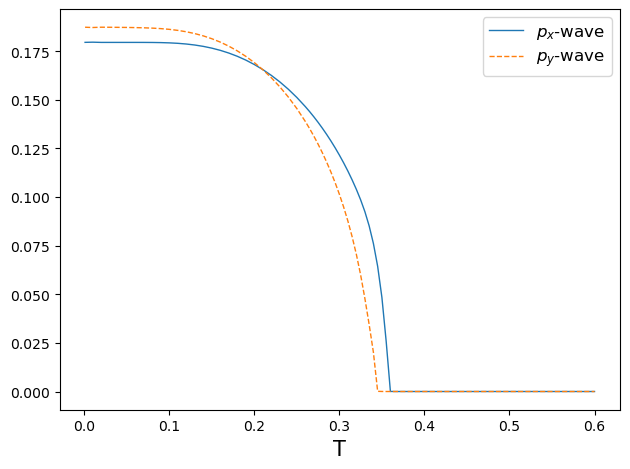

In [11]:
    plt.figure(1)
    plt.clf()
    plt.plot(T_list, np.real(F_px_arr), linewidth=1, label=r"$p_x$-wave")
    plt.plot(T_list, np.imag(F_py_arr), "--", linewidth=1, label=r"$p_y$-wave")

    plt.xlabel("T", fontsize=15)
    plt.legend(loc="best", fontsize=12)
    plt.tight_layout()
    plt.show()
